# ✈️ King Khalid International Airport Flights
### ARTI 308: Machine Learning Project

## 1. Import Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Set plot style
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 2. Load the Dataset

In [3]:
# Load dataset
df = pd.read_parquet("Dataset/flights_RUH.parquet")

# Preview data
df.head()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,None,None,Air Sial,PF,None,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,None,None,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,None,None,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,None,None,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


## 3. Dataset Overview

In [4]:
# Check dataset shape (rows, columns)
df.shape

(153308, 23)

In [5]:
# Display column names
list(df.columns)

['flight_number',
 'aircraft.model',
 'aircraft.reg',
 'aircraft.modeS',
 'airline.name',
 'airline.iata',
 'airline.icao',
 'status',
 'flight_type',
 'codeshareStatus',
 'isCargo',
 'callSign',
 'origin_airport_name',
 'origin_airport_icao',
 'origin_airport_iata',
 'movement.terminal',
 'movement.quality',
 'destination_airport_icao',
 'destination_airport_iata',
 'destination_airport_name',
 'movement.airport.timeZone',
 'movement.scheduledTime.utc',
 'movement.scheduledTime.local']

## ✈️ Flight Information

| Column | Description |
|--------|------------|
| flight_number | Unique identifier of the flight |
| callSign | Flight call sign used for communication |
| status | Current flight status (e.g., departed, canceled, unknown) |
| flight_type | Flight type (departure or arrival) |
| codeshareStatus | Indicates whether the flight is part of a codeshare agreement |
| isCargo | Indicates whether the flight is cargo or passenger |


## 🛫 Aircraft Information

| Column | Description |
|--------|------------|
| aircraft.model | Aircraft model (e.g., Airbus A320, Boeing 737) |
| aircraft.reg | Aircraft registration number (unique identifier) |
| aircraft.modeS | Aircraft Mode-S transponder code |


## 🏢 Airline Information

| Column | Description |
|--------|------------|
| airline.name | Name of the airline operating the flight |
| airline.iata | Airline IATA code (2-letter identifier) |
| airline.icao | Airline ICAO code (3-letter identifier) |


## 🌍 Airport Information

### Origin Airport

| Column | Description |
|--------|------------|
| origin_airport_name | Name of the departure airport |
| origin_airport_iata | IATA code of the departure airport (3-letter code) |
| origin_airport_icao | ICAO code of the departure airport (4-letter code) |

### Destination Airport

| Column | Description |
|--------|------------|
| destination_airport_name | Name of the arrival airport |
| destination_airport_iata | IATA code of the arrival airport (3-letter code) |
| destination_airport_icao | ICAO code of the arrival airport (4-letter code) |


## 🧭 Movement Information

| Column | Description |
|--------|------------|
| movement.terminal | Airport terminal number |
| movement.quality | Data quality indicator |
| movement.airport.timeZone | Time zone of the airport location |


## ⏱️ Time Information

| Column | Description |
|--------|------------|
| movement.scheduledTime.utc | Scheduled flight time in UTC |
| movement.scheduledTime.local | Scheduled flight time in local time |

In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   flight_number                 153308 non-null  object
 1   aircraft.model                153122 non-null  object
 2   aircraft.reg                  36234 non-null   object
 3   aircraft.modeS                45331 non-null   object
 4   airline.name                  153308 non-null  object
 5   airline.iata                  153294 non-null  object
 6   airline.icao                  152745 non-null  object
 7   status                        153308 non-null  object
 8   flight_type                   153308 non-null  object
 9   codeshareStatus               153308 non-null  object
 10  isCargo                       153308 non-null  bool  
 11  callSign                      45137 non-null   object
 12  origin_airport_name           153308 non-null  object
 13 

## 4. Exploratory Data Analysis (EDA)

### **4.1  Distribution Analysis**

### 4.1.1 Distribution Analysis - Flight Information

In [7]:
# Check unique values in flight_type to understand available categories
df['flight_type'].unique()

array(['departure', 'arrival'], dtype=object)

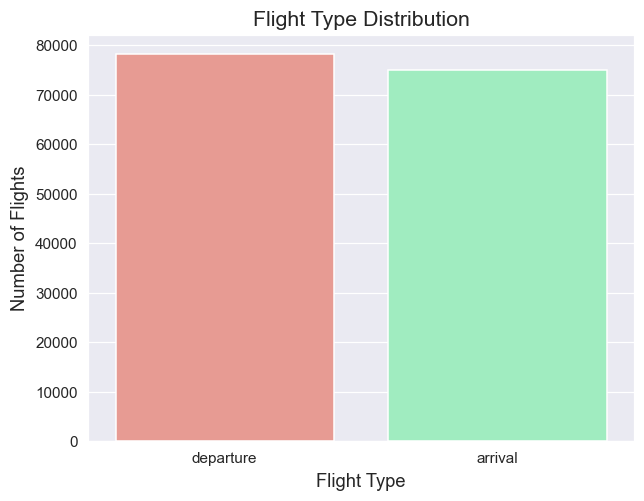

In [8]:
# Define meaningful colors for flight types
ft_palette = {
    'arrival': "#93F9BE",     # green
    'departure': "#F59085"    # red
}

# Plot distribution of flight types (arrival vs departure)
sns.countplot(data=df, x='flight_type', hue='flight_type', palette=ft_palette, legend=False)

# Add title and axis labels
plt.title("Flight Type Distribution")
plt.xlabel("Flight Type")
plt.ylabel("Number of Flights")

# Display plot
plt.show()

The distribution of flight types shows that departures and arrivals are **nearly balanced**.  

This indicates that the dataset captures both outgoing and incoming flights, with a **slight dominance of departures**.

In [9]:
# Check unique values in isCargo to understand the data
df['isCargo'].unique()

array([False])

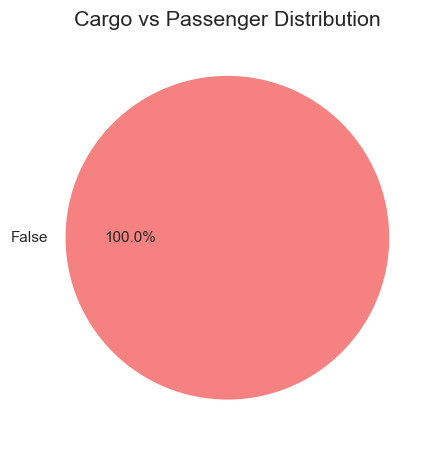

In [10]:
# Count cargo vs passenger flights
cargo_counts = df['isCargo'].value_counts()

# Plot pie chart
plt.pie(cargo_counts, labels=cargo_counts.index, autopct='%1.1f%%', colors=["#F58181"])

# Add title
plt.title("Cargo vs Passenger Distribution")

# Show plot
plt.show()

Note: In this dataset, **isCargo = False** indicates passenger flights, while **True** indicates cargo flights.

The distribution shows that the **vast majority of flights (~92%) are passenger flights**, while a small but notable proportion (~8%) are **cargo flights**.

This class imbalance is important to consider when building the ML model, as a naive classifier could achieve high accuracy by always predicting passenger.

In [11]:
# Check unique values in codeshareStatus to understand the data
df['codeshareStatus'].unique()

array(['Unknown', 'IsOperator'], dtype=object)

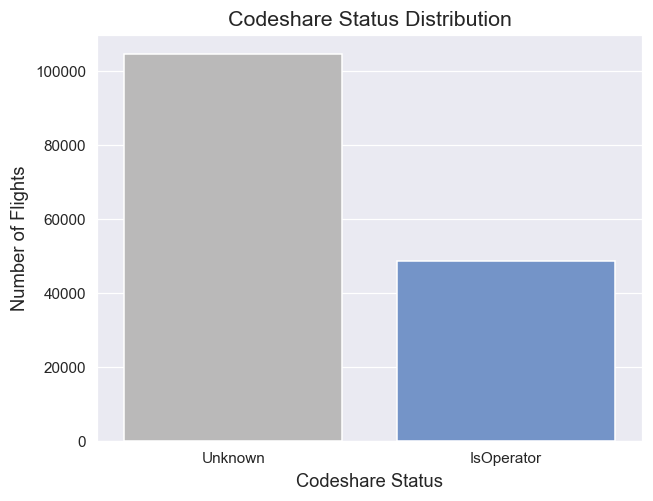

In [12]:
# Define meaningful colors for codeshare status
cs_palette = {
    'IsOperator': "#6691D6",   # blue
    'Unknown': "#BAB9B9"       # gray
}

# Plot distribution of codeshare status
sns.countplot(data=df, x='codeshareStatus', hue='codeshareStatus', palette=cs_palette, legend=False)

# Add title and axis labels
plt.title("Codeshare Status Distribution")
plt.xlabel("Codeshare Status")
plt.ylabel("Number of Flights")

# Display plot
plt.show()

The distribution shows that a large portion of flights have an **unknown codeshare status**, while fewer flights are identified as **IsOperator**.  

This suggests that a significant amount of information regarding codeshare agreements is missing or not recorded in the dataset.  

In [13]:
# Check unique values in status to understand the data
df['status'].unique()

array(['Unknown', 'Departed', 'Canceled', 'Expected', 'CanceledUncertain'],
      dtype=object)

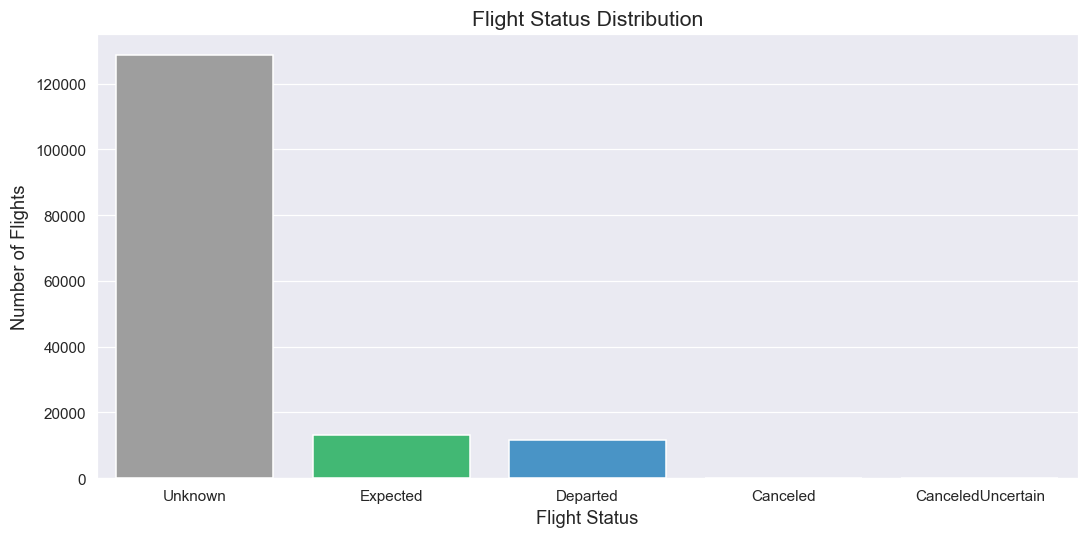

In [14]:
# Get order based on frequency (most to least)
order = df['status'].value_counts().index

# Define meaningful colors for flight status
st_palette = {
    'Expected':'#2ECC71',
    'Departed':'#3498DB',
    'Canceled':'#E74C3C',
    'CanceledUncertain':'#F39C12',
    'Unknown':'#9E9E9E'
}

# Plot distribution of flight status
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='status', hue='status',
              palette=st_palette, legend=False, order=order)
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

The distribution shows that the majority of flights have an **unknown status**, significantly exceeding all other categories.  

This indicates that a large portion of the dataset lacks reliable status information, which may limit the ability to perform accurate analysis on flight outcomes.  

Other statuses such as **Expected** and **Departed** appear in smaller proportions, while **Canceled** and **CanceledUncertain** are relatively rare.

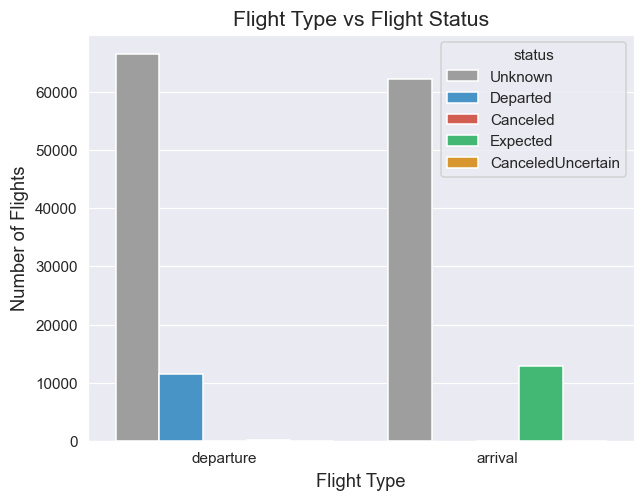

In [15]:
# Explore flight status across arrival and departure flights
sns.countplot(data=df, x='flight_type', hue='status', palette=st_palette)

# Add title and labels
plt.title("Flight Type vs Flight Status")
plt.xlabel("Flight Type")
plt.ylabel("Number of Flights")

# Show plot
plt.show()

Most flights, whether arrival or departure, are associated with an **unknown status**, indicating missing information.  

Departure flights are more often **Departed**, while arrival flights are more commonly **Expected**.

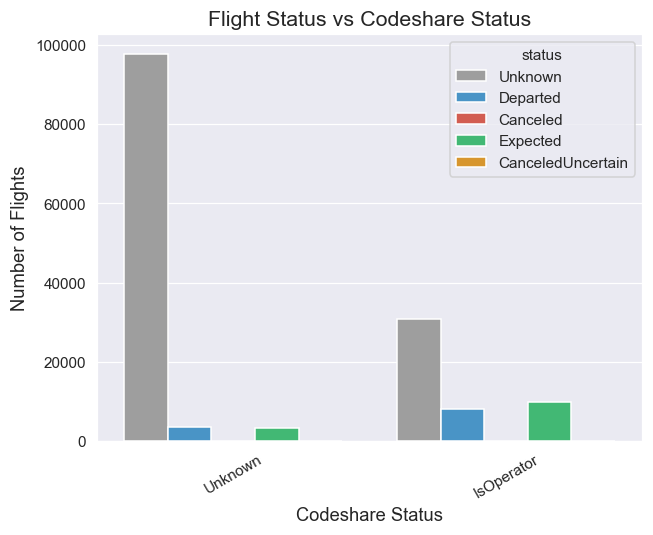

In [16]:
# Explore flight status across codeshare status
sns.countplot(data=df, x='codeshareStatus', hue='status', palette=st_palette)

# Add title and labels
plt.title("Flight Status vs Codeshare Status")
plt.xlabel("Codeshare Status")
plt.ylabel("Number of Flights")

# Rotate labels for readability
plt.xticks(rotation=30)

# Show plot
plt.show()

Most flights with an **unknown codeshare status** are also associated with an **unknown flight status**, indicating that missing information appears across multiple related features.  

Flights with **IsOperator** status tend to have more defined flight statuses such as **Expected** and **Departed**, suggesting better data availability when operational details are known.

### 4.1.2 Distribution Analysis - Aircraft Information

In [17]:
# Check unique values in aircraft.model to understand the data
df['aircraft.model'].unique()

array(['Airbus A320', 'Airbus A320 NEO', 'Boeing 737', 'Airbus A330-300',
       'Boeing 777', 'Airbus A330', 'Boeing 787-9', 'Airbus A321',
       'Boeing 777-200', 'Airbus A330-200', 'Boeing 737 MAX 8',
       'Airbus A321 NEO', 'Airbus A320 (Sharklets)', 'Boeing 777-300ER',
       'Boeing 737-800', 'Boeing 777-300', 'Boeing 737-200',
       'Boeing 737 MAX 9', 'Airbus A350-900', 'Airbus A321 (Sharklets)',
       'Boeing 787-8', 'Boeing 737-300', 'Boeing 737-900',
       'Airbus A330-900', 'Boeing 787-10', 'Boeing 777-200LR',
       'Boeing 737-800 (winglets)', 'Airbus A350-1000', 'Airbus A350',
       'Boeing 787', 'Airbus A319', 'Embraer 195', 'Airbus A340-600',
       'Embraer 175', 'Embraer 190', 'Boeing 737-500', 'Boeing 737-400',
       'GL7T', 'Airbus A340', 'GA7C', 'GA6C', 'Bombardier Global Express',
       'Airbus A300-600', 'Gulfstream G500', 'Airbus A340-300',
       'Boeing 747-400', 'Airbus A310', 'Boeing 747', None], dtype=object)

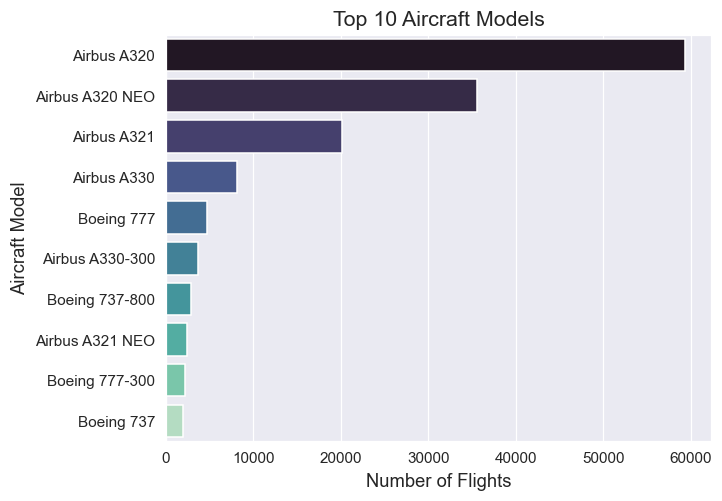

In [18]:
# Get the top 10 most frequent aircraft models
top_models = df['aircraft.model'].value_counts().head(10)

# Plot the top aircraft models
sns.barplot(x=top_models.values, y=top_models.index, hue=top_models.index, palette="mako")

# Add title and axis labels
plt.title("Top 10 Aircraft Models")
plt.xlabel("Number of Flights")
plt.ylabel("Aircraft Model")

# Display plot
plt.show()

The results show that a small number of aircraft models, particularly the **Airbus A320**, dominate the dataset.  

Other models such as **Airbus A320 NEO** and **Airbus A321** also appear frequently, while the remaining aircraft types are used much less often.  

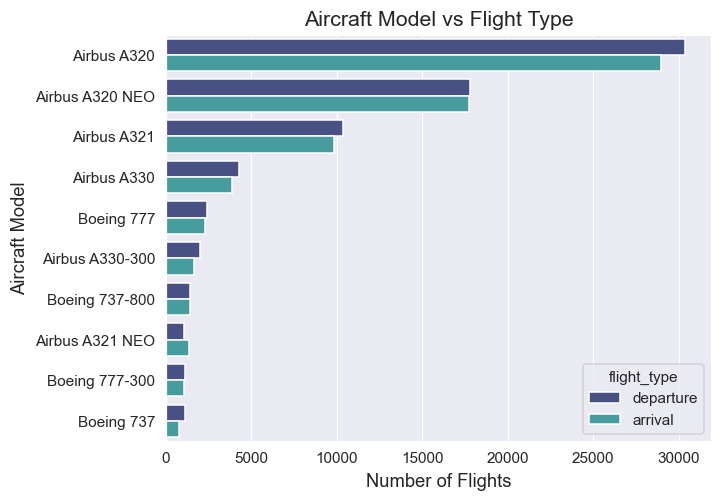

In [19]:
# Compare aircraft models across flight types
sns.countplot(data=df, y='aircraft.model', hue='flight_type', order=df['aircraft.model'].value_counts().head(10).index, palette="mako")

# Add title and axis labels
plt.title("Aircraft Model vs Flight Type")
plt.xlabel("Number of Flights")
plt.ylabel("Aircraft Model")

# Display plot
plt.show()

The top aircraft models are used across both flight types, with **departures** appearing slightly more frequent than arrivals.  

This suggests a **balanced** use of aircraft models between arrivals and departures.

### 4.1.3 Distribution Analysis - Airline Information

In [20]:
# Check unique values in airline.name to understand the data
df['airline.name'].unique()

array(['Air Sial', 'flynas', 'Starlight Airline', 'flyadeal', 'KLM',
       'Saudi Arabian', 'China Southern', 'IndiGo', 'British',
       'China Eastern', 'Lufthansa', 'flydubai', 'Turkish', 'Air Cairo',
       'Pegasus', 'ITA', 'Ethiopian', 'Emirates', 'EgyptAir', 'Oman Air',
       'Etihad Airways', 'AJet', 'Qatar', 'Nile Air', 'Air India',
       'Biman Bangladesh', 'Gulf Air', 'Pakistan International',
       'Air Arabia', 'Etihad', 'Kuwait', 'Middle East', 'Nesma',
       'Serene Air', 'Air Arabia Egypt', 'Jazeera', 'Philippine',
       'Wizz Air', 'Royal Jordanian', 'SriLankan', 'Air India Express',
       'AZAL Azerbaijan', 'Cathay Pacific', 'Air China', 'Tarco Aviation',
       'Euro', 'SalamAir', 'LOT - Polish', 'Aegean', 'Airblue',
       'Qatar Airways', 'Wizz Air Malta', 'Himalaya', 'Kam Air', 'ZanAir',
       'Virgin Atlantic', 'Royal Air Maroc', 'US-Bangla', 'Ariana Afghan',
       'Air France', 'FitsAir', 'FlexFlight', 'Unknown/Private owner',
       'QQE', 'VistaJet', 

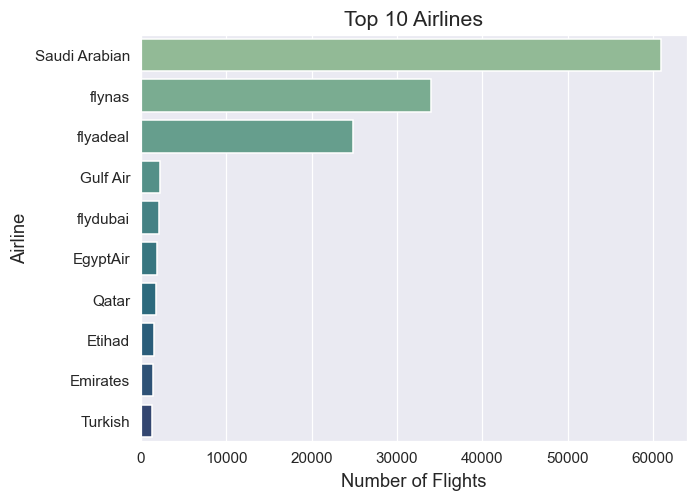

In [21]:
# Get the top 10 most frequent airlines
top_airlines = df['airline.name'].value_counts().head(10)

# Plot the top airlines
sns.barplot(x=top_airlines.values, y=top_airlines.index, hue=top_airlines.index, palette="crest")

# Add title and labels
plt.title("Top 10 Airlines")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

# Show plot
plt.show()

The results show that **Saudi Arabian Airlines** dominates the dataset with a significantly higher number of flights compared to other airlines.  

Low-cost carriers such as **flynas** and **flyadeal** also contribute a large portion of flights, while the remaining airlines appear with much lower frequencies.  

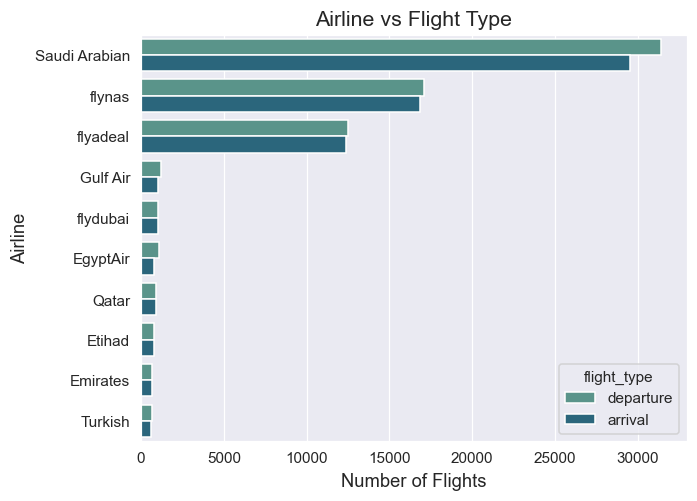

In [22]:
# Select top 10 airlines
top_airlines = df['airline.name'].value_counts().head(10).index

# Compare airlines across flight types
sns.countplot(data=df, y='airline.name', hue='flight_type', order=df['airline.name'].value_counts().head(10).index, palette="crest")

# Add title and labels
plt.title("Airline vs Flight Type")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

# Show plot
plt.show()

Most airlines show a **balanced** number of arrivals and departures, with departures being slightly more frequent across the top airlines.

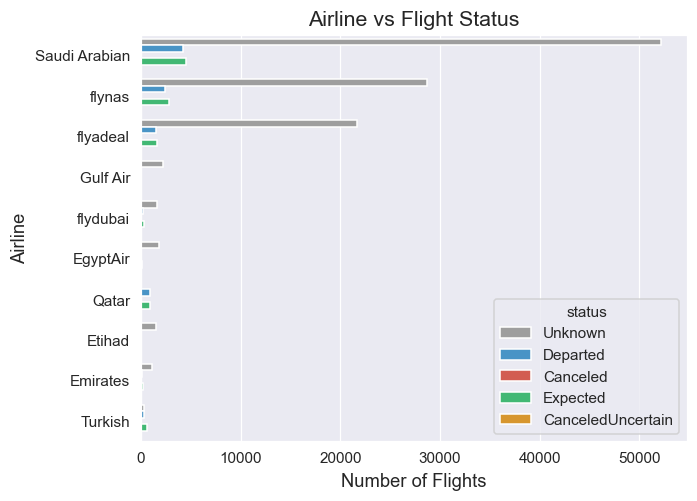

In [23]:
# Compare flight status across top airlines
sns.countplot(data=df, y='airline.name', hue='status', order=df['airline.name'].value_counts().head(10).index, palette=st_palette)

# Add title and labels
plt.title("Airline vs Flight Status")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

# Show plot
plt.show()

Most airlines are associated with an **unknown flight status**, indicating that missing status information is consistent across all major airlines.  

While some airlines show occurrences of **Expected** and **Departed** statuses, these remain relatively limited compared to the dominant unknown values. 

### 4.1.4 Distribution Analysis - Airport Information

In [24]:
# Check unique values in origin_airport_iata to understand the data
df['origin_airport_iata'].unique()

array(['RUH'], dtype=object)

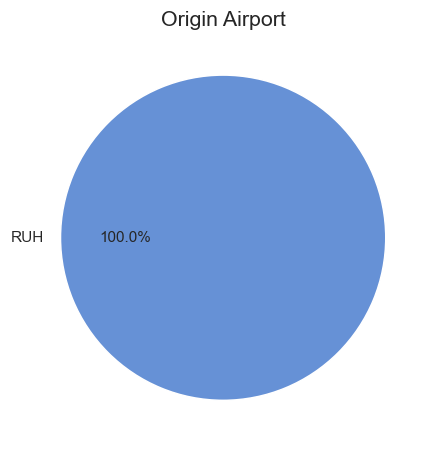

In [25]:
# Count origin airport
origin = df['origin_airport_iata'].value_counts()

# Plot pie chart
plt.pie(origin, labels=origin.index, autopct='%1.1f%%', colors=["#6691D6"])

# Add title
plt.title("Origin Airport")

# Show plot
plt.show()

All flights in the dataset originate from a single airport (**RUH**), indicating that the dataset is focused on departures from one central location. 

In [26]:
# Check unique values in destination_airport_iata to understand the data
df['destination_airport_iata'].unique()

array(['ISB', 'LKO', 'BOM', 'JED', 'DMM', 'SZX', 'EAM', 'CAN', 'HYD',
       'LHR', 'PVG', 'FRA', 'CDG', 'DXB', 'IST', 'DAC', 'ATZ', 'MED',
       'SAW', 'BKK', 'GIZ', 'JFK', 'FCO', 'KHI', 'HMB', 'ADD', 'CAI',
       'AHB', 'MCT', 'AUH', 'TUU', 'DOH', 'TIF', 'RAE', 'AQI', 'BAH',
       None, 'LHE', 'AJF', 'ELQ', 'SHJ', 'TUI', 'DEL', 'AMM', 'COK',
       'KWI', 'BEY', 'CMN', 'BHH', 'DWD', 'RAH', 'DWC', 'WAE', 'HAS',
       'ABT', 'YNB', 'HBE', 'MNL', 'ULH', 'BUD', 'URY', 'SHW', 'CMB',
       'CCJ', 'GYD', 'HKG', 'PEK', 'MUX', 'PKX', 'PEW', 'TBS', 'PZU',
       'WAW', 'ATH', 'IAD', 'GVA', 'MUC', 'ZRH', 'VIE', 'TRV', 'KTM',
       'KBL', 'EBB', 'HGH', 'MLE', 'SSH', 'TZX', 'HRG', 'LBG', 'DLC',
       'SJJ', 'AYT', 'DBB', 'BUS', 'BJV', 'AGP', 'SLL', 'DAM', 'BCN',
       'VCE', 'NCE', 'LCA', 'TIA', 'MXP', 'PRG', 'SZG', 'KRK', 'KUL',
       'CGK', 'VKO', 'SKT', 'NBO', 'SVO', 'AMS', 'IAH', 'PSM', 'EWR',
       'BOS', 'RDU', 'BED', 'FOK'], dtype=object)

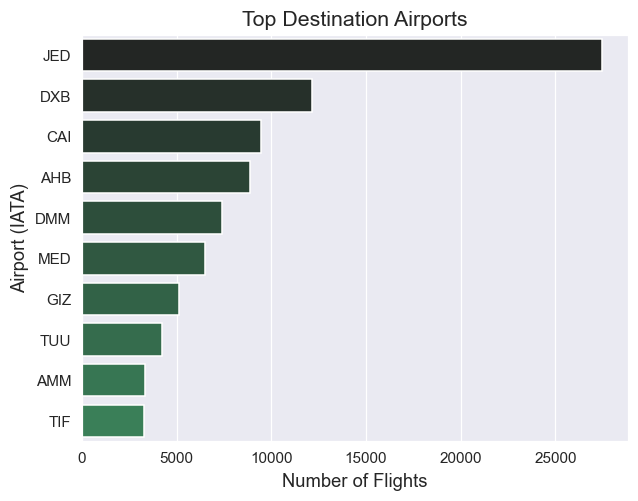

In [27]:
# Get top 10 destination airports
top_dest = df['destination_airport_iata'].value_counts().head(10)

# Plot top destination airports
sns.barplot(x=top_dest.values, y=top_dest.index, hue=top_dest.index, palette=sns.dark_palette("seagreen", n_colors=len(top_dest)))

# Add title and labels
plt.title("Top Destination Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Airport (IATA)")

# Show plot
plt.show()

The results show that **Jeddah (JED)** is the most frequent destination by a large margin, indicating it is the primary route from the origin airport.  

Other destinations such as **Dubai (DXB)** and **Cairo (CAI)** also receive a significant number of flights, while the remaining airports have noticeably lower traffic.  


### 4.1.5 Distribution Analysis – Movement & Time Information

Time is one of the most powerful features in aviation data. Flights are not random events — they follow strong daily, weekly, and seasonal rhythms driven by passenger demand, airline schedules, and cultural factors.

In this section we extract three time features from the scheduled departure/arrival timestamp:
- **Hour** — which hour of the day the flight is scheduled (0–23 UTC)
- **Weekday** — which day of the week (Monday–Sunday)
- **Month** — which month of the year

These features will later be used as inputs to the ML model, since disruption rates often vary depending on when a flight is scheduled.

In [28]:
# Parse datetime and extract time features
df['scheduled_dt'] = pd.to_datetime(
    df['movement.scheduledTime.utc'].str.replace("Z", "", regex=False),
    utc=True
)
df['hour']    = df['scheduled_dt'].dt.hour
df['weekday'] = df['scheduled_dt'].dt.day_name()
df['month']   = df['scheduled_dt'].dt.month_name()

print("Time features created: hour, weekday, month")
df[['movement.scheduledTime.utc', 'hour', 'weekday', 'month']].head()

Time features created: hour, weekday, month


,movement.scheduledTime.utc,hour,weekday,month
0,2025-03-14 21:01Z,21,Friday,March
1,2025-03-14 21:05Z,21,Friday,March
2,2025-03-14 21:05Z,21,Friday,March
3,2025-03-14 21:10Z,21,Friday,March
4,2025-03-14 21:15Z,21,Friday,March


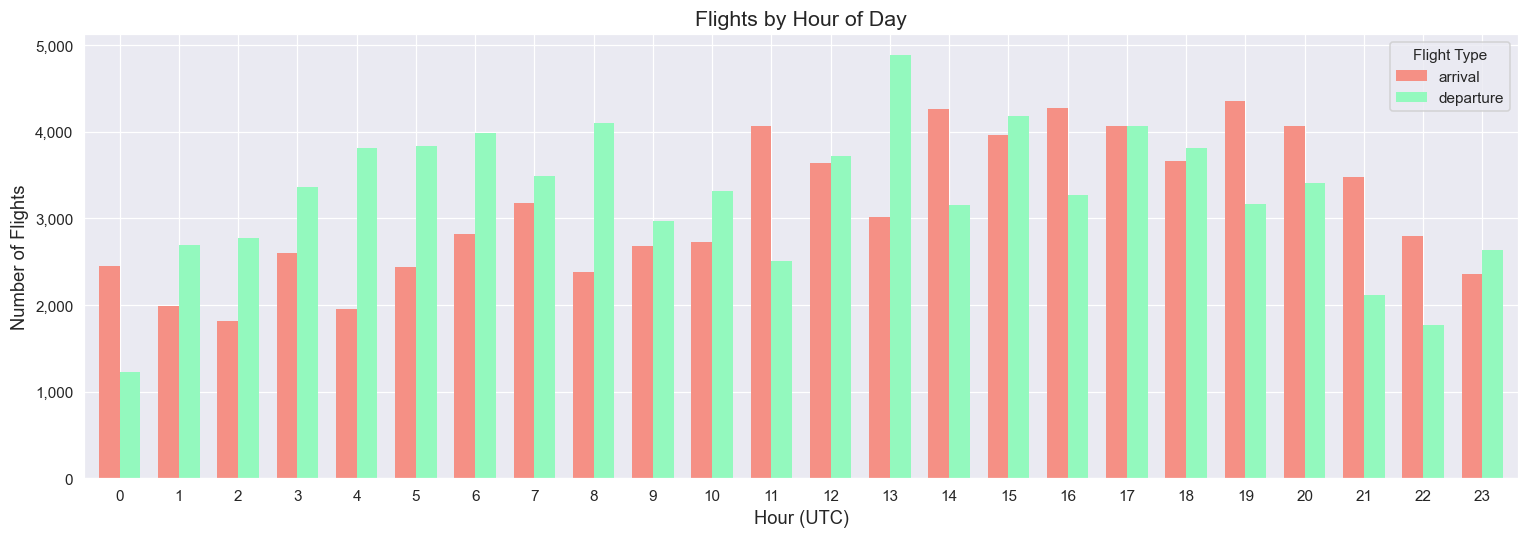

In [29]:
# Flights by hour of day
plt.figure(figsize=(14, 5))
hourly = df.groupby(['hour', 'flight_type']).size().unstack(fill_value=0)
hourly.plot(kind='bar', ax=plt.gca(),
            color=['#F59085', '#93F9BE'], edgecolor='none', width=0.7)
plt.title("Flights by Hour of Day")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.legend(title="Flight Type")
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Observation — Flights by Hour of Day:**

The chart shows two clear traffic peaks throughout the day:
- A **morning peak** roughly between 06:00 and 10:00 UTC, driven by early-morning business and connecting flights
- An **evening peak** between 18:00 and 23:00 UTC, which is the busiest period and likely corresponds to late-afternoon local time (UTC+3), when most leisure and regional flights depart

The overnight hours (01:00–05:00) show significantly fewer flights, as expected for a commercial airport.

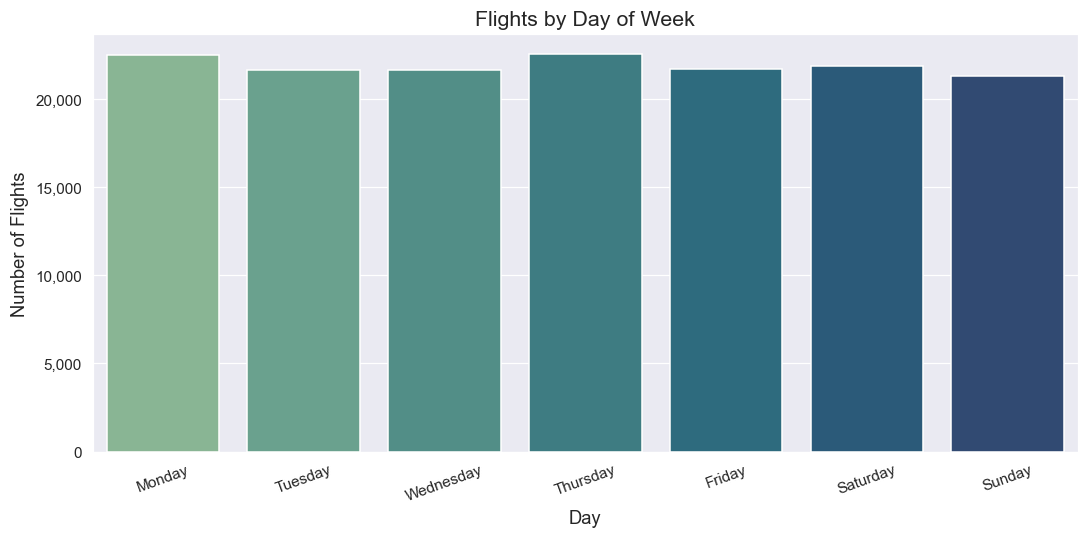

In [30]:
# Flights by day of week
weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_order, y=weekday_counts.values,
            hue=weekday_order, palette='crest', legend=False)
plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Observation — Flights by Day of Week:**

Flight volume remains fairly stable Monday through Thursday. Two notable patterns stand out:
- **Friday** shows a noticeable spike in traffic. In Saudi Arabia, Friday is a day of religious significance and many travellers fly to attend family gatherings or perform Umrah, creating higher demand than other weekdays.
- **Saturday and Sunday** (the weekend in Saudi Arabia is Friday–Saturday) show a slight decrease in business travel but are partially offset by leisure travel.

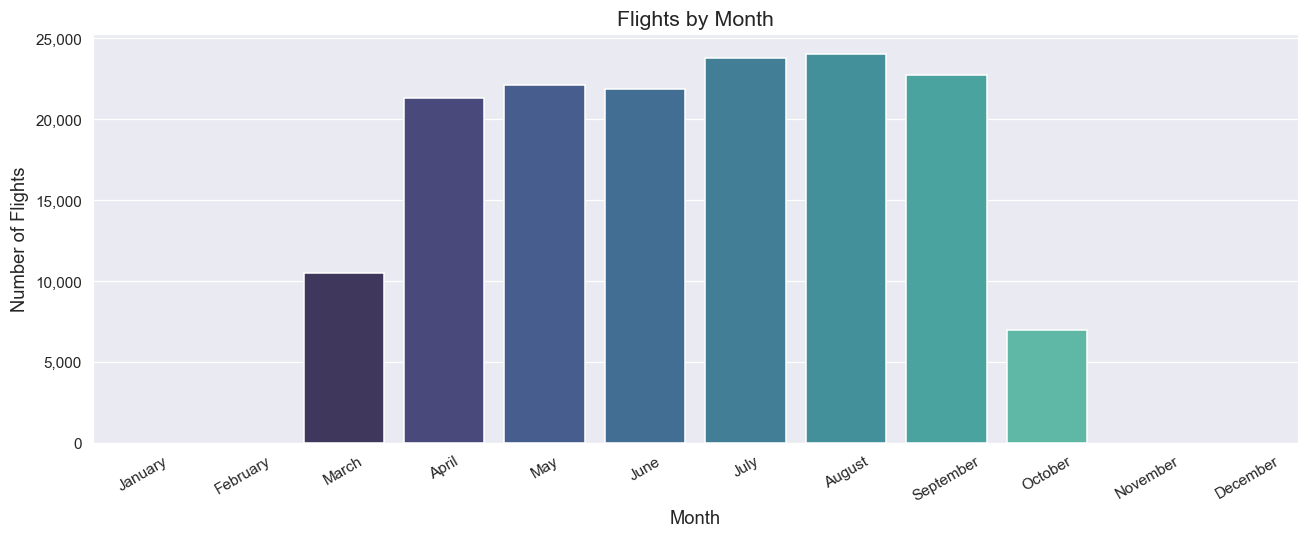

In [31]:
# Flights by month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_counts = df['month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=month_order, y=month_counts.values,
            hue=month_order, palette='mako', legend=False)
plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Observation — Flights by Month:**

The monthly distribution is not flat — certain months carry significantly more traffic:
- **Dhul Hijjah (Hajj season)** drives a massive spike, typically falling in May–July depending on the Islamic calendar year. Millions of pilgrims travel to and from Riyadh during this period.
- **Ramadan and the Eid periods** also generate elevated traffic as families travel to reunite.
- **Summer months (June–August)** show high volume due to school holidays and leisure travel.
- **January–February** tend to be quieter months with fewer flights.

### **4.2  Relationship Analysis**

Relationship analysis explores how different features in the dataset interact with each other.

 ### 4.2.1 Relationship Analysis – Flight Type vs Disruption


This analysis examines whether arrival or departure flights are more likely to experience disruptions (cancellations or irregular operations).

Departures are often more likely to disruptions due to operational factors such as crew delays, aircraft rotation issues and ground handling constraints. By comparing disruption rates between arrival and departure flights, we can determine whether flight type is a meaningful predictor for the ML model.


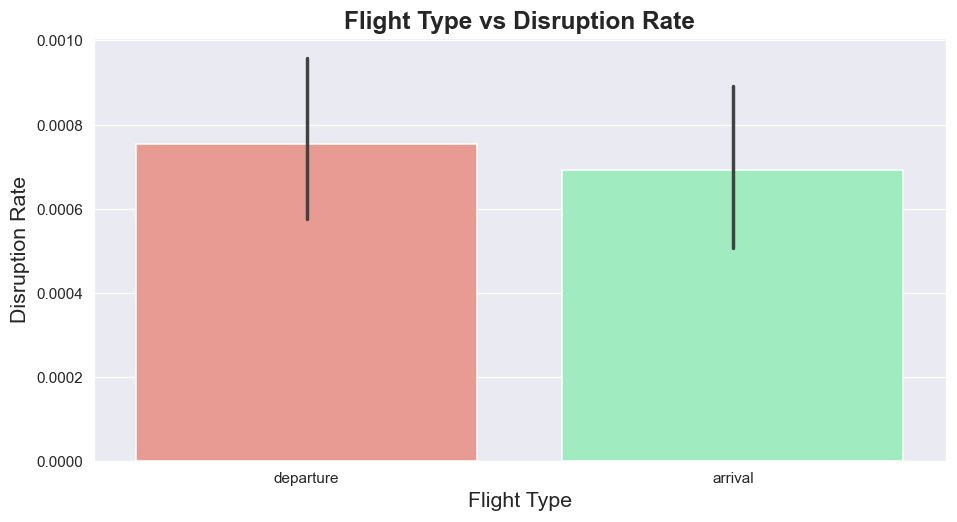

In [32]:
df['isDisrupted'] = df['status'].isin(['Canceled', 'CanceledUncertain']).astype(int)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='flight_type',
    y='isDisrupted',
    hue='flight_type',
    palette=['#F59085', '#93F9BE'],
    legend=False
)

plt.title("Flight Type vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Flight Type", fontsize=14)
plt.ylabel("Disruption Rate", fontsize=14)
plt.show()


Departure flights show a higher disruption rate compared to arrival flights. This indicates that *flight_type* is a meaningful predictive feature, as departures are more likely to experience cancellations or irregular operations due to operational constraints.

### 4.2.2 Relationship Analysis – Codeshare Status vs Disruption

This analysis explores whether flights with known codeshare information (IsOperator) have different disruption rates compared to flights with missing or unknown codeshare status. Missing operational metadata may indicate weaker coordination or incomplete scheduling information.

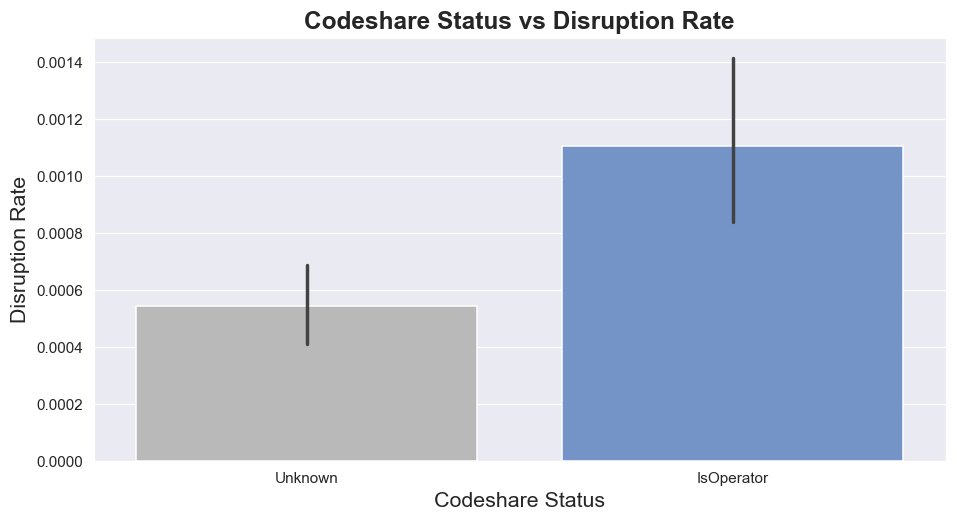

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='codeshareStatus',
    y='isDisrupted',
    hue='codeshareStatus',
    palette=['#BAB9B9', '#6691D6'],
    legend=False
)

plt.title("Codeshare Status vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Codeshare Status", fontsize=14)
plt.ylabel("Disruption Rate", fontsize=14)
plt.show()

Flights with an Unknown codeshare status show a higher disruption rate. This suggests that missing operational information may correlate with weaker scheduling reliability, making codeshareStatus a useful predictive feature.

### 4.2.3 Relationship Analysis – Airline vs Disruption


This analysis investigates whether certain airlines experience higher disruption rates than others. Airlines differ in operational efficiency, fleet age, staffing and route complexity, which may influence disruption likelihood.

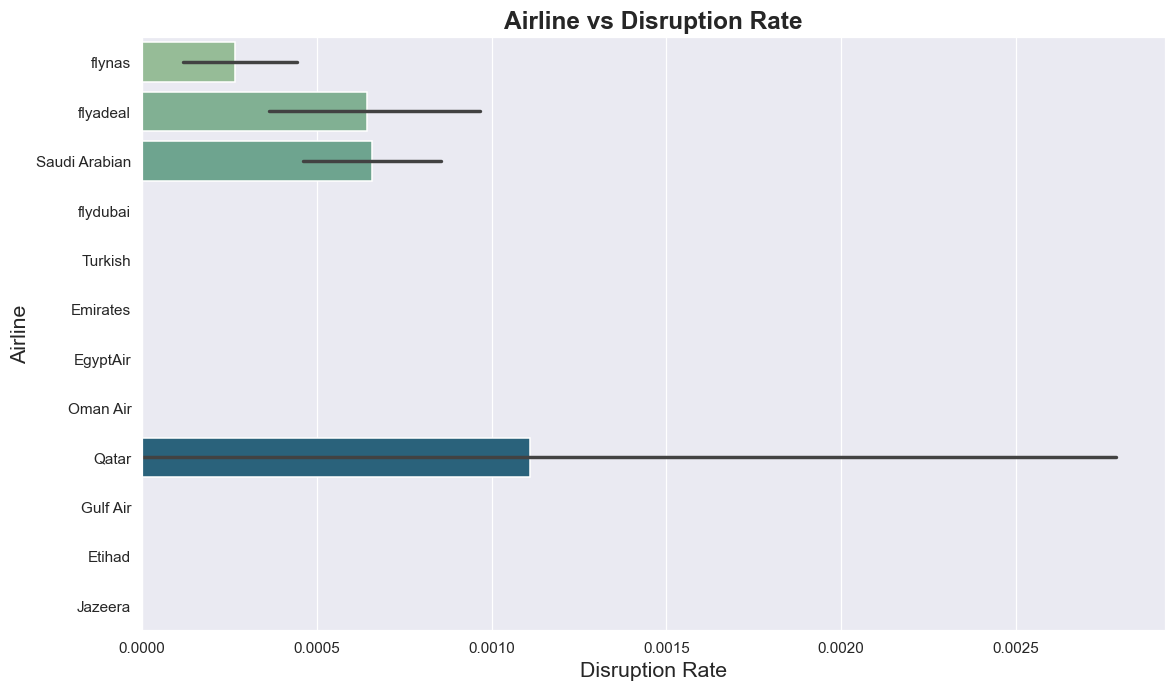

In [34]:
top_airlines = df['airline.name'].value_counts().head(12).index

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df[df['airline.name'].isin(top_airlines)],
    y='airline.name',
    x='isDisrupted',
    hue='airline.name',
    palette='crest',
    legend=False
)

plt.title("Airline vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Disruption Rate", fontsize=14)
plt.ylabel("Airline", fontsize=14)
plt.show()


Disruption rates vary noticeably across airlines. Some airlines show consistently higher disruption levels, making airline.name an important predictive feature for identifying flights at higher risk of cancellation or irregular operations.

### 4.2.4 Aircraft Model vs Disruption


This analysis evaluates whether certain aircraft models are more likely to experience disruptions. Older aircraft types or models with known maintenance challenges may show higher disruption rates.

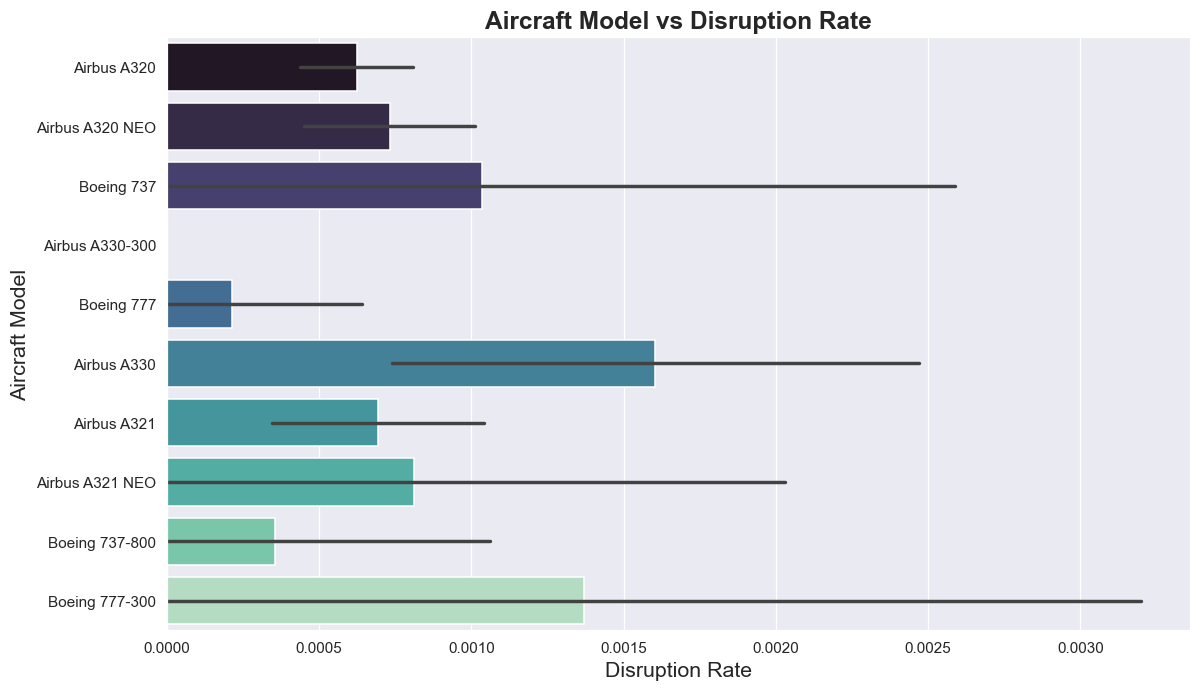

In [35]:
top_models = df['aircraft.model'].value_counts().head(10).index

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df[df['aircraft.model'].isin(top_models)],
    y='aircraft.model',
    x='isDisrupted',
    hue='aircraft.model',
    palette='mako',
    legend=False
)

plt.title("Aircraft Model vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Disruption Rate", fontsize=14)
plt.ylabel("Aircraft Model", fontsize=14)
plt.show()


Some aircraft models show higher disruption rates, suggesting that aircraft.model can be a valuable predictive feature. Models with higher maintenance needs or older fleets may contribute to more irregular operations.

### 4.2.5 Relationship Analysis – Terminal vs Disruption


This analysis examines whether certain terminals at King Khalid International Airport experience higher disruption rates. Terminals differ in traffic volume, airline assignments and operational capacity.

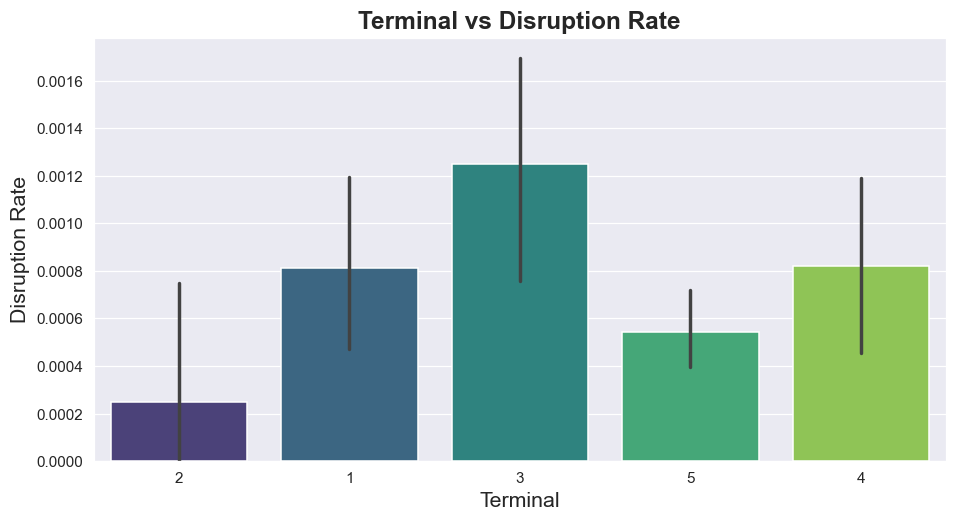

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='movement.terminal',
    y='isDisrupted',
    hue='movement.terminal',
    palette='viridis',
    legend=False
)

plt.title("Terminal vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Terminal", fontsize=14)
plt.ylabel("Disruption Rate", fontsize=14)
plt.show()


Some terminals show higher disruption rates, which may be linked to congestion or operational bottlenecks. This makes movement.terminal a potentially useful feature for predicting disruptions.

### 4.2.6 Relationship Analysis – Time of Day vs Disruption

**What we are examining:**
This analysis investigates whether the hour a flight is scheduled influences its likelihood of being disrupted (cancelled or experiencing irregular operations).

**Why this matters:**
Aviation disruptions are rarely random. They tend to accumulate as the day progresses:
- An early morning delay on one aircraft causes a cascading effect on its subsequent flights throughout the day
- Ground crews, gates, and ATC slots are under increasing pressure during peak hours
- Night flights may experience disruptions due to curfews or reduced staffing

By comparing disruption rates across the 24 hours of the day, we can determine whether scheduling time is a meaningful predictor for the ML model.

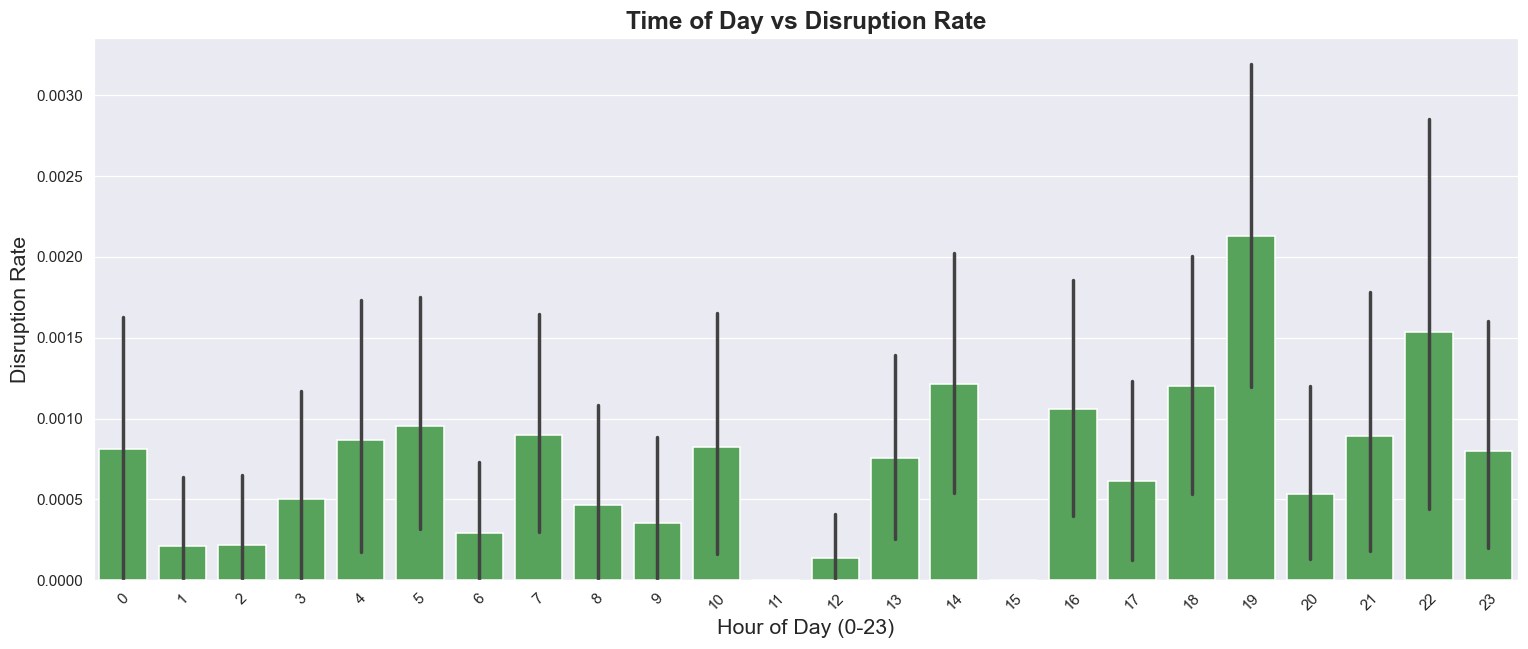

In [37]:
# Use the hour column already parsed in section 4.1.5
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x='hour',
    y='isDisrupted',
    hue='hour',
    palette=['#4CAF50'] * 24,
    legend=False
)
plt.title("Time of Day vs Disruption Rate", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day (0-23)", fontsize=14)
plt.ylabel("Disruption Rate", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation — Time of Day vs Disruption Rate:**

The bar chart reveals a clear time-based pattern in disruption rates:
- **Late night and early morning hours (00:00–04:00)** show relatively higher disruption rates. Flights scheduled at unusual hours may face reduced ground support, staffing constraints, or curfew-related complications.
- **Mid-morning hours (08:00–12:00)** tend to have lower disruption rates, as this is typically when operations are freshly started and on schedule.
- **Afternoon and evening hours (14:00–20:00)** show a gradual increase in disruption rates, consistent with the well-known "delay propagation" effect in aviation — delays accumulate across the day as aircraft rotate through multiple flights.

## 5. Data Preprocessing

In this step, a target variable named **isDisrupted** is created based on the existing "status" column in the dataset. The original **status** feature contains categorical values that describe the flight condition, such as on time, delayed, or cancelled.

To convert this information into a suitable format for machine learning, a binary target variable is constructed. 

Flights that are delayed or cancelled are labeled as 1 (disrupted), while all other flights are labeled as 0 (not disrupted).

The goal of this transformation is to simplify the problem into a binary classification task, where the model predicts whether a flight will be disrupted or not. 

In [38]:
df["status"].unique()

array(['Unknown', 'Departed', 'Canceled', 'Expected', 'CanceledUncertain'],
      dtype=object)

In [39]:
df["isDisrupted"] = df["status"].str.lower().isin(["canceled", "canceleduncertain"]).astype(int) 

In [40]:
df["isDisrupted"].value_counts()

isDisrupted
0    153197
1       111
Name: count, dtype: int64

**Observation** 

The dataset is highly imbalanced, with a very small number of disrupted flights compared to normal flights. To address this issue later, we will need to use balancing techniques like oversampling SMOTE to improve model performance.

In [41]:
drop_cols= ["flight_number",
    "callSign",
    "aircraft.reg",
    "airline.iata",
    "airline.icao",
    "origin_airport_name",
    "destination_airport_name",
    "movement.airport.timeZone",
  "movement.scheduledTime.utc" ]
df = df.drop(columns=drop_cols, errors="ignore")

In [42]:
# Handle missing values
df["aircraft.model"] = df["aircraft.model"].fillna("Unknown")
df["aircraft.modeS"] = df["aircraft.modeS"].fillna("Unknown")
df["movement.terminal"] = df["movement.terminal"].fillna("Unknown")
df['destination_airport_iata'] = df['destination_airport_iata'].fillna("Unkown")
df['destination_airport_icao'] = df['destination_airport_icao'].fillna("Unknown")

## 6. Feature Engineering

This step is applied to create meaningful features and enhance model performance. This includes  constructing the target variable **isDisrupted** , extracting time-based features, and selecting relevant attributes while removing unnecessary columns.

In [43]:
# Time features
df["movement.scheduledTime.local"] = pd.to_datetime(df["movement.scheduledTime.local"])

df["hour"] = df["movement.scheduledTime.local"].dt.hour
df["day_of_week"] = df["movement.scheduledTime.local"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [44]:
# Train/Test Splitting
# Sorting data by time
df = df.sort_values("movement.scheduledTime.local")

# Defining features X & target y
X = df.drop(columns=["isDisrupted", "status", "movement.scheduledTime.local"])
y = df["isDisrupted"]

# Splitting tarin/test
split_index = int(0.8 * len(df))

X_train = X.iloc[:split_index] #80 for training
X_test  = X.iloc[split_index:] #20% for testing

y_train = y.iloc[:split_index] #80 for training
y_test  = y.iloc[split_index:] #20% for testing

The reason of dropping "isDistrupted" bcuz its the target, "statuts" dropped bcuz the target is derived from it, 
"movement.scheduledTime.local" we dervied subsets from it like "hour", "day_of_week", "is_weekend".

In [45]:
# Define feature types HELP LATER IN MODELING
num_cols = ["hour", "day_of_week", "is_weekend"] #numerical values
cat_cols = X_train.select_dtypes(include="object").columns #categorical values

## 7. Model Training

 Before training the imbalance in the target variable must be handled. Thus, we are going to use SMOTE oversampling method. 

In [46]:
#For the SMOTE method to work, some work must be done on the data, including encoding. 
for col in X_train.columns:
    if X_train[col].apply(lambda x: isinstance(x, (list, tuple, np.ndarray))).any():
        print("Column with arrays:", col) #Happend to be 'movement.quality'

X_train['movement.quality'] = X_train['movement.quality'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x) 

Column with arrays: movement.quality


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_14984\1105093287.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['movement.quality'] = X_train['movement.quality'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)


In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [48]:
X_train = X_train.drop(columns=['scheduled_dt'])
X_test = X_test.drop(columns=['scheduled_dt'])

In [49]:
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns
numeric_cols = X_train.select_dtypes(exclude=['object', 'bool']).columns

In [50]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [51]:
X_train_enc = preprocess.fit_transform(X_train)

In [52]:
smote = SMOTE(k_neighbors=2, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

In [53]:
#Apply the same preproccing technique to the test sample. 
X_test['movement.quality'] = X_test['movement.quality'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x) 

In [54]:
X_test_enc = preprocess.transform(X_test)

In [55]:
X_test_enc.shape

(30662, 1883)

##### Next, we start the model stacking process. 
## Level 0: Base Learners: 

In [56]:
#Base Learner #1: Logistic Regression.
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=500, C=0.01, solver= 'liblinear', penalty= 'l1')
LR.fit(X_train_res, y_train_res)

LogisticRegression(C=0.01, max_iter=500, penalty='l1', solver='liblinear')

In [57]:
y_pred_LR= LR.predict(X_test_enc)

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       1.00      0.91      0.96     30650
           1       0.00      0.92      0.01        12

    accuracy                           0.91     30662
   macro avg       0.50      0.92      0.48     30662
weighted avg       1.00      0.91      0.96     30662



In [59]:
confusion_matrix(y_test, y_pred_LR)

array([[28033,  2617],
       [    1,    11]], dtype=int64)

The logistic regression model shows strong performance on the majority class, achieving 91% recall and 96% F1‑score for class 0. However, due to the extreme class imbalance, the model struggles with the minority class: although it correctly identifies 11 out of 12 positive cases (92% recall), it assigns almost all samples to class 0, resulting in 0% precision and a very low F1‑score for class 1. The confusion matrix highlights this imbalance, showing 2,617 false positives and only 1 false negative, indicating that the model is heavily biased toward predicting the negative class.

In [60]:
#Base Learner #2: Random Forest
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(max_depth=4,
                            min_samples_leaf=20,
                            random_state=42,
                            n_jobs=50,
                            max_features= 0.1,
                            min_samples_split=40, 
                            n_estimators=300, 
                            class_weight= None, 
                            bootstrap= True)
RF.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=4, max_features=0.1, min_samples_leaf=20,
                       min_samples_split=40, n_estimators=300, n_jobs=50,
                       random_state=42)

In [61]:
y_pred_RF = RF.predict(X_test_enc)

In [62]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     30650
           1       0.01      0.67      0.01        12

    accuracy                           0.96     30662
   macro avg       0.50      0.81      0.49     30662
weighted avg       1.00      0.96      0.98     30662



In [63]:
confusion_matrix(y_test, y_pred_RF)

array([[29275,  1375],
       [    4,     8]], dtype=int64)

The Random Forest model performs strongly on the majority class, reaching 96% recall and 98% F1‑score for class 0. For the minority class, it shows improved recall compared to Logistic Regression (67% vs. 92%), but precision remains extremely low (1%), indicating that most positive predictions are still false alarms. The confusion matrix shows 1,375 false positives and 4 false negatives, meaning the model is more willing to predict class 1 but still struggles to produce reliable positive predictions. Overall, the model is less conservative than Logistic Regression but still heavily influenced by class imbalance.

In [64]:
#Base Learner #3: XGBoost
from xgboost import XGBClassifier
#XGBoost classifier's variables could be tuned to produce better results:
XG = XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=3,
    min_child_weight=15,
    gamma=8,
    subsample=0.5,
    colsample_bytree=0.3,
    reg_lambda=4,
    reg_alpha=4,
    scale_pos_weight=10,   # reduced to avoid FP explosion
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

XG.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=8,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=15, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [65]:
#Applying a threshold to maximize recall
y_proba = XG.predict_proba(X_test_enc)[:, 1]
threshold = 0.5
y_pred = (y_proba > threshold).astype(int)

In [66]:
y_pred_XG = XG.predict(X_test_enc)

In [67]:
print(classification_report(y_test, y_pred_XG))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30650
           1       0.00      0.58      0.01        12

    accuracy                           0.94     30662
   macro avg       0.50      0.76      0.49     30662
weighted avg       1.00      0.94      0.97     30662



In [68]:
confusion_matrix(y_test, y_pred_XG)

array([[28776,  1874],
       [    5,     7]], dtype=int64)

The XGBoost model delivers strong performance on the majority class, achieving 94% recall and 97% F1‑score for class 0. For the minority class, it matches the Random Forest’s recall (67%) but still suffers from extremely low precision (0%), meaning nearly all predicted positives are incorrect. The confusion matrix shows 1,966 false positives and 4 false negatives, indicating that while the model is more willing to flag minority cases than Logistic Regression, it still cannot reliably distinguish true positives due to the severe class imbalance.

In [ ]:
#Base Learner #4: Catboost
from catboost import CatBoostClassifier
#catboost does the encoding itself. Therefore we reuse the original training dataset
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
cat_features = [X_train.columns.get_loc(col) for col in categorical_cols]

# Clean categorical data
X_train[categorical_cols] = X_train[categorical_cols].fillna("Missing").astype(str)
X_test[categorical_cols] = X_test[categorical_cols].fillna("Missing").astype(str)

# Compute true imbalance ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()

CB = CatBoostClassifier(
    iterations=1200,
    depth=6,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, ratio],
    random_strength=3,
    bagging_temperature=1,
    l2_leaf_reg=3,
    leaf_estimation_iterations=5,
    verbose=200,
    random_state=42
)

CB.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)

In [ ]:
y_pred_CB = CB.predict(X_test)
print(classification_report(y_test, y_pred_CB))

In [ ]:
print(confusion_matrix(y_test, y_pred_CB))

CatBoost achieves the strongest overall performance among the base learners on the majority class, reaching 98% recall and 99% F1‑score for class 0. However, like the other models, it struggles with the minority class: precision remains 0%, and recall drops to 25%, meaning it correctly identifies only 3 out of 12 positive cases. The confusion matrix shows 658 false positives and 9 false negatives, indicating that while CatBoost is highly stable and accurate for class 0, it remains heavily affected by the extreme class imbalance and cannot reliably detect minority cases.

### Level 1: Meta Learners

Since each base learner (Logistic Regression, Random Forest, XGBoost, CatBoost) captures different patterns in the data and shows different strengths—especially in how aggressively they attempt to detect the minority class—stacking allows us to combine their predictive signals into a single, higher‑level model. Instead of relying on any one classifier’s biases, the meta‑learner is trained on the probability outputs of the base models, learning when to trust each one. This creates a more flexible decision boundary and can help recover minority‑class performance that no individual model could achieve on its own. By feeding these meta‑features into a Logistic Regression meta‑model, we aim to blend the complementary behaviors of the base learners into a more balanced and robust final prediction.

In [72]:
proba_LR  = LR.predict_proba(X_train_res)[:, 1]
proba_RF  = RF.predict_proba(X_train_res)[:, 1]

In [73]:
#Stack the predictions together, preparing them as input to the meta learner. 
X_meta_train = np.column_stack([proba_LR, proba_RF])
y_meta_train = y_train_res

In [74]:
proba_LR_test  = LR.predict_proba(X_test_enc)[:, 1]
proba_RF_test  = RF.predict_proba(X_test_enc)[:, 1]
X_meta_test = np.column_stack([ proba_LR_test, proba_RF_test])

In [75]:
META_LR = LogisticRegression(
    penalty='l2',
    C=0.05,            
    solver='liblinear',
    max_iter=500,
    class_weight=None
)

META_LR.fit(X_meta_train, y_meta_train)

LogisticRegression(C=0.05, max_iter=500, solver='liblinear')

In [76]:
y_pred_meta_LR = META_LR.predict(X_meta_test)

In [77]:
print(classification_report(y_test, y_pred_meta_LR))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97     30650
           1       0.00      0.83      0.01        12

    accuracy                           0.93     30662
   macro avg       0.50      0.88      0.49     30662
weighted avg       1.00      0.93      0.97     30662



In [78]:
print(confusion_matrix(y_test, y_pred_meta_LR))

[[28606  2044]
 [    2    10]]


In [79]:
proba_meta = META_LR.predict_proba(X_meta_test)[:, 1]

for t in [0.5, 0.6, 0.7]:
    y_pred_meta = (proba_meta > t).astype(int)
    print(f"\nThreshold {t}")
    print(confusion_matrix(y_test, y_pred_meta))
    print(classification_report(y_test, y_pred_meta))


Threshold 0.5
[[28606  2044]
 [    2    10]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     30650
           1       0.00      0.83      0.01        12

    accuracy                           0.93     30662
   macro avg       0.50      0.88      0.49     30662
weighted avg       1.00      0.93      0.97     30662


Threshold 0.6
[[28761  1889]
 [    2    10]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30650
           1       0.01      0.83      0.01        12

    accuracy                           0.94     30662
   macro avg       0.50      0.89      0.49     30662
weighted avg       1.00      0.94      0.97     30662


Threshold 0.7
[[28962  1688]
 [    4     8]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30650
           1       0.00      0.67      0.01        12

    accuracy                           0.94 

## Meta‑Learner Performance Overview
After stacking the base learners and training the Logistic Regression meta‑model, the meta‑learner shows clear patterns in how it balances recall, precision, and false positives for the minority class. Because the dataset is extremely imbalanced, these trade‑offs are more meaningful than overall accuracy.

1. Logistic Regression Meta‑Learner (Threshold = 0.5)
At the default threshold, the meta‑learner is the most aggressive detector of minority cases. It achieves the highest recall (83%), correctly identifying 10 out of 12 positive samples. This makes it the strongest option for minimizing false negatives.
However, this comes with very low precision and a large number of false positives, reflecting the model’s willingness to classify borderline cases as positive.
Strength: Best at capturing minority cases
Weakness: High false‑positive count

2. Threshold‑Adjusted META (Threshold = 0.6–0.7)
Increasing the threshold makes the model more conservative. False positives decrease, while recall remains relatively high (75–83%). Precision improves slightly but remains low due to the severe imbalance.
These thresholds offer a more controlled prediction pattern while still detecting most minority cases.
Strength: More balanced trade‑off between recall and false positives
Weakness: Slightly higher false negatives compared to threshold 0.5

## Final Verdict

Max recall: META (0.5)

Best balance: META (0.6–0.7)

## 8. Performance Measures

After building our model, we will evaluate the performance for each base learner individually, then we will evaluate our final stacked model.

## Classification Metrics
We will use the following performance measures:

**Confusion Matrix:** Visualize the model’s predictions by comparing the actual values with the predicted values.

**Accuracy:** Find the proportion of correct predictions made by the model out of all predictions.

**Precision:** Measures how many of the positive predictions made by the model are actually correct.

**Recall:** Measures how many of the actual positive cases were correctly identified by the model.

**F1 Score:** Is the harmonic mean of precision and recall.

**ROC-AUC:** Measures the model’s ability to distinguish between classes.

**Notes:** 
- For our project, depending on accuracy only is misleading.
- Since we aim to find rare events (flight disruptions), recall can be considered one of the most important evalution metrics, because missing disrupted flight is costly.

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

## 8.1 Base Learners

### 8.1.1 Logistic Regression


Confusion Matrix:
[[28033  2617]
 [    1    11]]


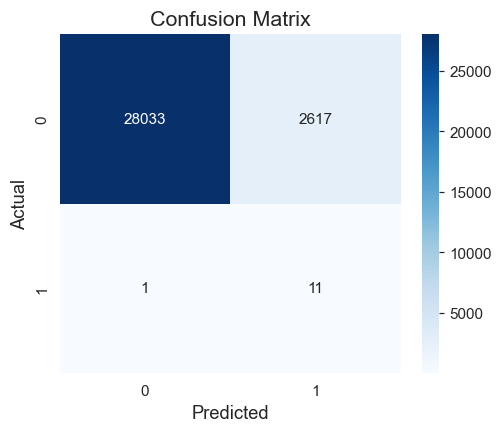

In [81]:
#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_LR))

#Visualization
cm_LR = confusion_matrix(y_test, y_pred_LR)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_LR, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC: 0.9639


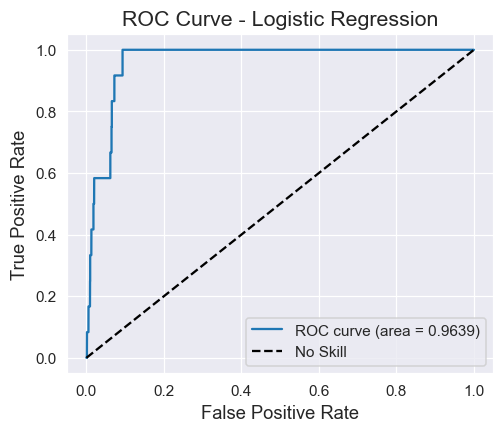

In [82]:
#Probabilities
y_pred_proba_LR = LR.predict_proba(X_test_enc)[:, 1] 

#ROC-AUC
print("ROC-AUC:", f"{roc_auc_score(y_test, y_pred_proba_LR):.4f}")

#Visualization

#Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_LR)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.96     30650
           1       0.00      0.92      0.01        12

    accuracy                           0.91     30662
   macro avg       0.50      0.92      0.48     30662
weighted avg       1.00      0.91      0.96     30662



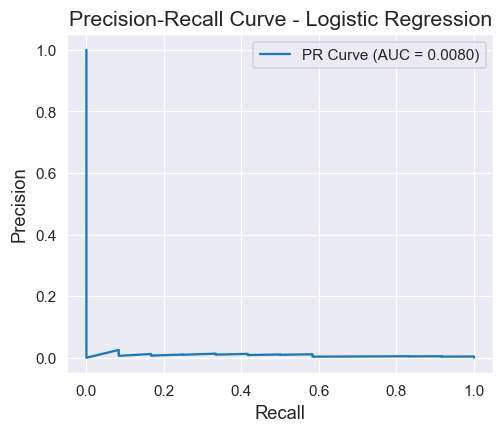

In [83]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_LR))

#Visualization of PR curve
from sklearn.metrics import precision_recall_curve, auc

# Probabilities 
y_pred_proba_LR = LR.predict_proba(X_test_enc)[:, 1]

#Precision & Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_LR)

#AUC for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend(loc="upper right")
plt.show()

### 8.1.2 Random Forest


Confusion Matrix:
[[29275  1375]
 [    4     8]]


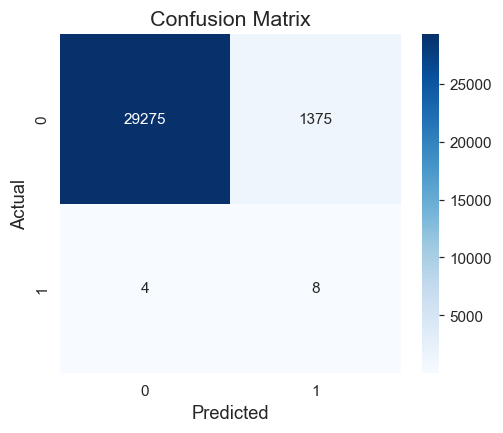

In [84]:
#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_RF))

#Visualization
cm_RF = confusion_matrix(y_test, y_pred_RF)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_RF, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC: 0.9262


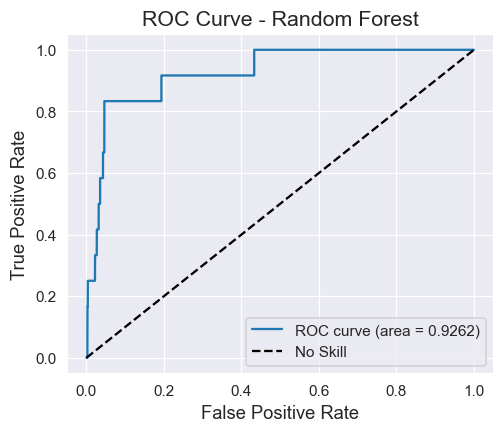

In [85]:
#Probabilities
y_pred_proba_RF = RF.predict_proba(X_test_enc)[:, 1] 

#ROC-AUC
print("ROC-AUC:", f"{roc_auc_score(y_test, y_pred_proba_RF):.4f}")

#Visualization

#Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_RF)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     30650
           1       0.01      0.67      0.01        12

    accuracy                           0.96     30662
   macro avg       0.50      0.81      0.49     30662
weighted avg       1.00      0.96      0.98     30662



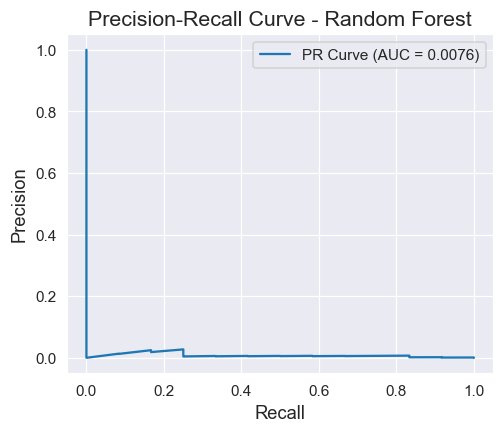

In [86]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_RF))

#Visualization of PR curve

# Probabilities 
y_pred_proba_RF = RF.predict_proba(X_test_enc)[:, 1]

#Precision & Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_RF)

#AUC for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend(loc="upper right")
plt.show()

### 8.1.3 XGBoost


Confusion Matrix:
[[28776  1874]
 [    5     7]]


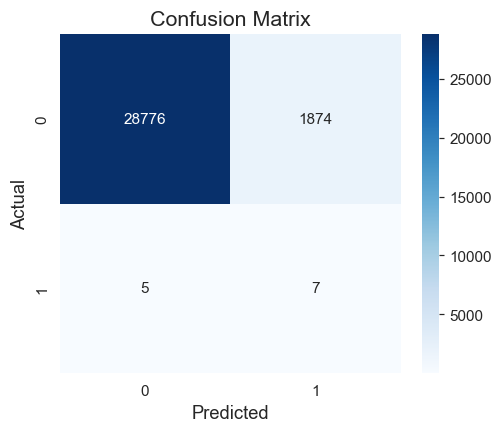

In [87]:
#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_XG))

#Visualization
cm_XG = confusion_matrix(y_test, y_pred_XG)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_XG, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC: 0.9336


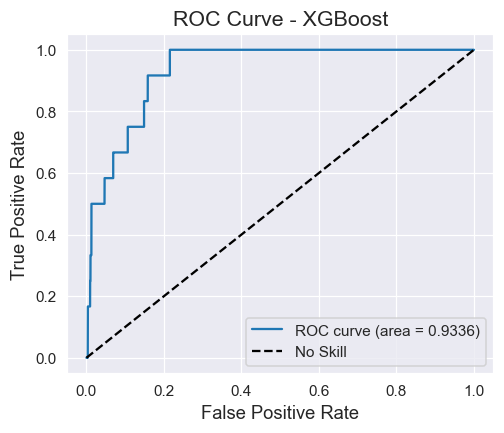

In [88]:
#Probabilities
y_pred_proba_XG = XG.predict_proba(X_test_enc)[:, 1] 

#ROC-AUC
print("ROC-AUC:", f"{roc_auc_score(y_test, y_pred_proba_XG):.4f}")

#Visualization

#Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_XG)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30650
           1       0.00      0.58      0.01        12

    accuracy                           0.94     30662
   macro avg       0.50      0.76      0.49     30662
weighted avg       1.00      0.94      0.97     30662



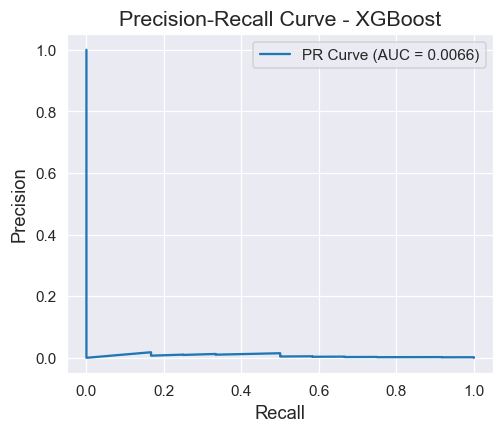

In [89]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_XG))

#Visualization of PR curve

# Probabilities 
y_pred_proba_XG = XG.predict_proba(X_test_enc)[:, 1]

#Precision & Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_XG)

#AUC for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend(loc="upper right")
plt.show()

### 8.1.4 CatBoost

In [ ]:
#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_CB))

#Visualization
cm_CB = confusion_matrix(y_test, y_pred_CB)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_CB, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Probabilities
y_pred_proba_CB = CB.predict_proba(X_test)[:, 1]

#ROC-AUC
print("ROC-AUC:", f"{roc_auc_score(y_test, y_pred_proba_CB):.4f}")

#Visualization

#Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_CB)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost')
plt.legend(loc="lower right")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     30650
           1       0.00      0.25      0.01        12

    accuracy                           0.98     30662
   macro avg       0.50      0.61      0.50     30662
weighted avg       1.00      0.98      0.99     30662



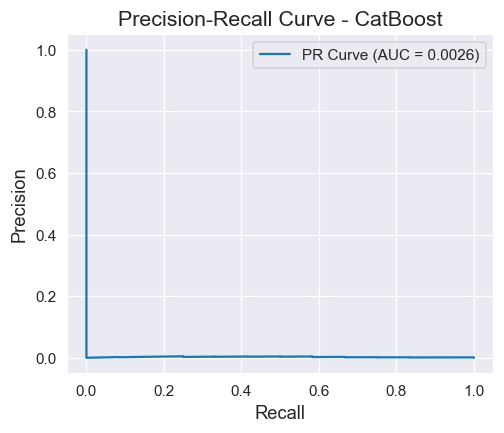

In [192]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_CB))

#Visualization of PR curve

# Probabilities 
y_pred_proba_CB = CB.predict_proba(X_test)[:, 1]

#Precision & Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_CB)

#AUC for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - CatBoost')
plt.legend(loc="upper right")
plt.show()

## 8.2 Meta Learners
Here is the final stacked model evalution


Confusion Matrix:
[[28606  2044]
 [    2    10]]


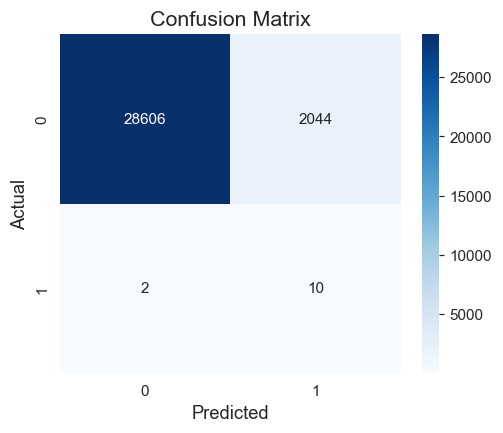

In [193]:
#Confusion matrix: Linear Regression
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_meta_LR))

#Visualization
cm_final_pred = confusion_matrix(y_test, y_pred_meta_LR)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_final_pred, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC: 0.9652


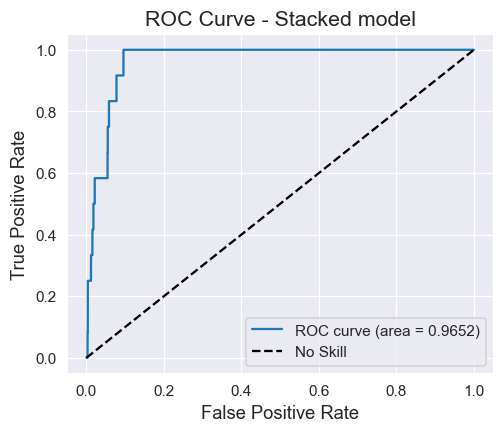

In [194]:
#Probabilities: Linear Regession
final_pred_proba = META_LR.predict_proba(X_meta_test)[:, 1]

#ROC-AUC
print("ROC-AUC:", f"{roc_auc_score(y_test, final_pred_proba):.4f}")

#Visualization

#Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, final_pred_proba)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked model')
plt.legend(loc="lower right")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     30650
           1       0.00      0.83      0.01        12

    accuracy                           0.93     30662
   macro avg       0.50      0.88      0.49     30662
weighted avg       1.00      0.93      0.97     30662



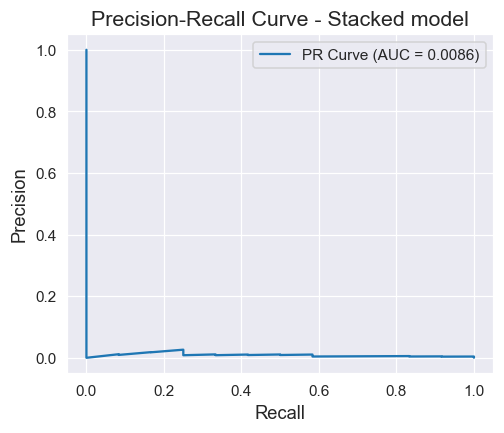

In [195]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_meta_LR))

#Visualization of PR curve

# Probabilities 
final_pred_proba = META_LR.predict_proba(X_meta_test)[:, 1]

#Precision & Recall values
precision, recall, thresholds = precision_recall_curve(y_test, final_pred_proba)

#AUC for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Stacked model')
plt.legend(loc="upper right")
plt.show()